# 03 — VAYU AQI Category Classifier
> **Input:** `data/cleaned/01_classification/clf_train_unscaled.csv`, `clf_test_unscaled.csv`  
> **Outputs:** `models/rf_classifier.pkl`, `models/xgb_classifier.pkl`, `models/best_classifier.pkl`, `models/classifier_metadata.json`  
> **Run after:** `01_eda_and_cleaning.ipynb`

---

## What This Notebook Does

Given current pollutant readings for a city, predict which **CPCB AQI category** the air quality falls into. This is a **4-class classification problem** — the dataset genuinely contains no Satisfactory or Severe readings after cleaning.

| Integer | Category | AQI Range | Health Signal |
|---------|----------|-----------|---------------|
| 0 | **Good** | 0–50 | Minimal impact |
| 2 | **Moderate** | 101–200 | Discomfort for asthma patients |
| 3 | **Poor** | 201–300 | ⚠️ Prolonged exposure risk - triggers CPCB health advisory |
| 4 | **Very Poor** | 301–400 | Respiratory illness on extended exposure |

> Classes 1 (Satisfactory) and 5 (Severe) are **genuinely absent** from the cleaned dataset. This is not a data bug — treat it as a 4-class problem.

---

## Class Distribution (After Cleaning)

| Category | Train rows | Share |
|----------|-----------|-------|
| Good | 107,564 | 16.2% |
| Moderate | 304,113 | 45.8% ← majority |
| Poor | 138,033 | 20.8% |
| Very Poor | 113,983 | 17.2% |

**Imbalance ratio: 2.8×** — mild; handled with `class_weight='balanced'` (RF) and `sample_weight` (XGBoost).

---

## Pipeline at a Glance

```
clf_train_unscaled.csv / clf_test_unscaled.csv
    │
    ├─ Section 0  Imports & config
    ├─ Section 1  Load data, validate features, plot class distribution
    ├─ Section 2  Train Random Forest (200 trees, balanced class weight)
    ├─ Section 3  Train XGBoost (300 trees, label remapping, sample weights)
    ├─ Section 4  Compare: per-class F1, confusion matrices, overall metrics
    ├─ Section 5  Feature importance (Gini vs Gain)
    ├─ Section 6  Confidence distribution (max predicted probability)
    ├─ Section 7  Inference function  ← Streamlit dashboard calls this
    └─ Section 8  Save models + metadata JSON
```

---

## Model Selection Decision (Spoiler)

> **XGBoost is the deployment model** despite slightly lower accuracy.

| | Random Forest | XGBoost |
|---|---|---|
| Accuracy | **0.793** | 0.745 |
| Weighted F1 | **0.793** | 0.748 |
| Poor class recall | 66.5% | **71.1%** ← clinically critical |
| Model size | ~3,045 MB ❌ | ~5.4 MB ✅ |
| Deployable on Render free tier? | No | **Yes** |

RF's accuracy advantage is almost entirely from Moderate (45.8% of data). XGBoost wins on **Poor** (AQI 201–300), the class that triggers CPCB health advisories.


# VAYU — Module 2: AQI Category Classifier

**Prerequisite:** Run `vayu_step4_classification.ipynb` first — this notebook reads the pre-split, pre-balanced classification CSVs.

---

### What This Module Does

Given current pollutant readings for a city, predict which of the 6 CPCB categories the air quality falls into:

| Integer | Category | AQI Range | Health Impact |
|---|---|---|---|
| 0 | Good | 0–50 | Minimal |
| 1 | Satisfactory | 51–100 | Minor breathing discomfort for sensitive people |
| 2 | Moderate | 101–200 | Breathing discomfort for asthma patients |
| 3 | Poor | 201–300 | Breathing discomfort on prolonged exposure |
| 4 | Very Poor | 301–400 | Respiratory illness on prolonged exposure |
| 5 | Severe | 401–500 | Affects healthy people; serious risk for sensitive groups |

### Models Trained
1. **Random Forest Classifier** — ensemble of decision trees, handles class imbalance, no scaling needed
2. **XGBoost Classifier** — gradient boosting, best predictive performance on tabular data

Both are trained, evaluated, and compared. The better model is saved as the production classifier.

### Steps in This Notebook
1. Load pre-split classification datasets
2. Train Random Forest (unscaled data)
3. Train XGBoost (unscaled data)
4. Evaluate both — classification report, confusion matrix, per-class accuracy
5. Compare models and select winner
6. Feature importance analysis
7. Prediction function (inference-ready)
8. Save models to disk

---
## Section 0 — Imports & Setup

In [2]:
!pip install joblib --quiet

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 40)

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR  = './data/cleaned/01_classification'
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── category metadata ─────────────────────────────────────────────────────────
CAT_ORDER  = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLORS = {
    'Good'        : '#00E400',
    'Satisfactory': '#92D050',
    'Moderate'    : '#FFFF00',
    'Poor'        : '#FF7E00',
    'Very Poor'   : '#FF0000',
    'Severe'      : '#99004C',
}
CAT_TO_INT = {cat: i for i, cat in enumerate(CAT_ORDER)}
INT_TO_CAT = {i: cat for i, cat in enumerate(CAT_ORDER)}

print('Setup complete.')
print(f'Data directory  : {os.path.abspath(DATA_DIR)}')
print(f'Model directory : {os.path.abspath(MODEL_DIR)}')


Setup complete.
Data directory  : d:\vayu\data\cleaned\01_classification
Model directory : d:\vayu\models


---
## Section 1 — Load Classification Datasets

Tree-based models (Random Forest, XGBoost) split on **threshold comparisons** — they are invariant to feature scale. We therefore use the **unscaled** CSVs. The scaled versions exist for distance-based models (e.g. SVM, kNN) used in other experiments.

**Validation checks run here:**
- Both CSV files exist (raises `FileNotFoundError` if `01_eda_and_cleaning.ipynb` wasn't run first)
- `aqi_category_enc` target column is present
- Feature list is loaded from `feature_list.txt` (or inferred from columns as fallback)
- NaN check — silently imputed with column median if found
- Class distribution plotted to confirm 4-class structure before training


---
## Section 1 — Load Classification Datasets

We load the **unscaled** CSVs for Random Forest and XGBoost — tree-based models do not require feature scaling because they split on thresholds, not distances.

In [4]:
TRAIN_PATH = os.path.join(DATA_DIR, 'clf_train_unscaled.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'clf_test_unscaled.csv')
LABEL_PATH = os.path.join(DATA_DIR, 'label_map.json')
FEAT_PATH  = os.path.join(DATA_DIR, 'feature_list.txt')

# ── validate files exist before loading ───────────────────────────────────────
for path in [TRAIN_PATH, TEST_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            f"Run vayu_step4_classification.ipynb first to generate the split CSVs."
        )

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'Test shape  : {test.shape[0]:,} rows x {test.shape[1]} columns')
print(f'\nColumns: {list(train.columns)}')


Train shape : 660,345 rows x 9 columns
Test shape  : 165,087 rows x 9 columns

Columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'month', 'hour', 'aqi_category_enc']


In [5]:
# ── target column names ──────────────────────────────────────────────────────
TARGET_INT = 'aqi_category_enc'   # integer label  (0–5)  — always required
TARGET_STR = 'aqi_category'       # string label   (Good…) — optional

# Validate target column exists
if TARGET_INT not in train.columns:
    raise ValueError(
        f"Target column '{TARGET_INT}' not found in training CSV.\n"
        f"Available columns: {list(train.columns)}"
    )

# ── load feature list ─────────────────────────────────────────────────────────
if os.path.exists(FEAT_PATH):
    with open(FEAT_PATH) as f:
        lines = f.readlines()
    FINAL_FEATURES = [
        l.strip().lstrip('- ')
        for l in lines
        if l.strip() and not l.strip().startswith(
            ('VAYU', '=', 'Target', 'Feature', 'Train', 'Test', 'SMOTE', 'File', 'clf_')
        )
    ]
    # Only keep features that actually exist in the CSV
    FINAL_FEATURES = [f for f in FINAL_FEATURES if f in train.columns]
    print(f'Loaded {len(FINAL_FEATURES)} features from feature_list.txt')
else:
    # Fallback: use all columns except targets
    COLS_TO_DROP   = [c for c in [TARGET_INT, TARGET_STR] if c in train.columns]
    FINAL_FEATURES = [c for c in train.columns if c not in COLS_TO_DROP]
    print(f'feature_list.txt not found — inferred {len(FINAL_FEATURES)} features from columns')

print(f'Features ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

# ── build X/y arrays ──────────────────────────────────────────────────────────
X_train = train[FINAL_FEATURES].values.astype(float)
y_train = train[TARGET_INT].values.astype(int)
X_test  = test[FINAL_FEATURES].values.astype(float)
y_test  = test[TARGET_INT].values.astype(int)

# ── validate class range ──────────────────────────────────────────────────────
unique_classes = sorted(np.unique(np.concatenate([y_train, y_test])))
present_cats   = [CAT_ORDER[i] for i in unique_classes if i < len(CAT_ORDER)]
print(f'\nClasses present : {unique_classes} → {present_cats}')

print(f'\nX_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

# Check for NaN in features — will silently break tree models
nan_train = np.isnan(X_train).sum()
nan_test  = np.isnan(X_test).sum()
if nan_train > 0 or nan_test > 0:
    print(f'\n⚠ WARNING: NaN values found — train:{nan_train}  test:{nan_test}')
    print('  Filling NaN with column median...')
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median')
    X_train = imp.fit_transform(X_train)
    X_test  = imp.transform(X_test)
    print('  ✅ NaN values filled.')
else:
    print('\n✅ No NaN values in features.')


feature_list.txt not found — inferred 8 features from columns
Features (8): ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'month', 'hour']

Classes present : [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] → ['Good', 'Moderate', 'Poor', 'Very Poor', 'Severe']

X_train: (660345, 8)   y_train: (660345,)
X_test : (165087, 8)   y_test : (165087,)

✅ No NaN values in features.


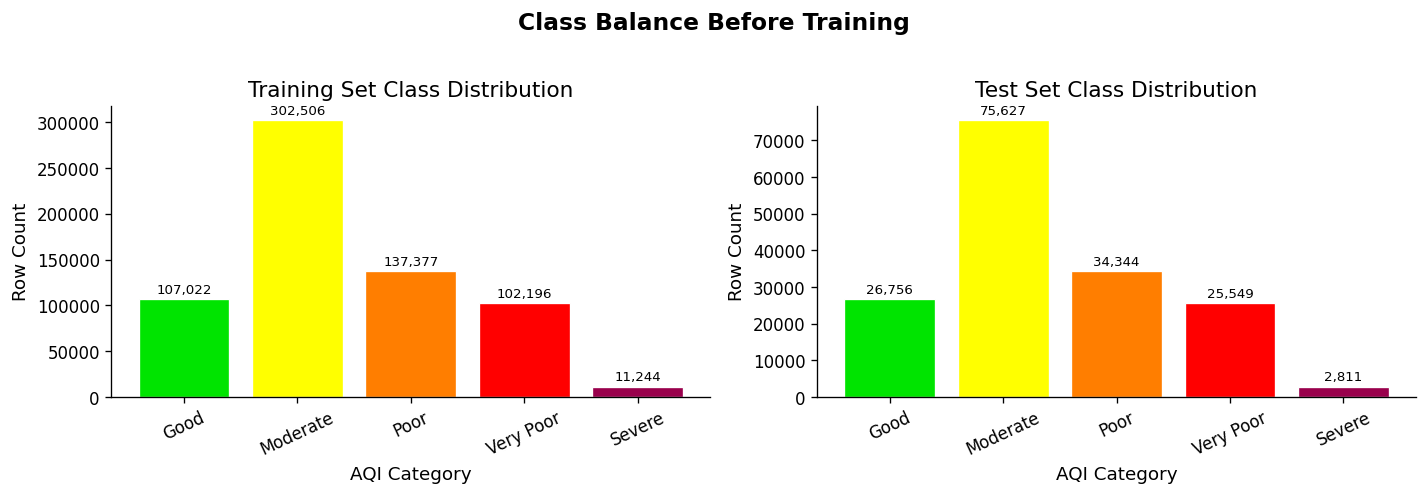

Train class counts:
Good         107022
Moderate     302506
Poor         137377
Very Poor    102196
Severe        11244

Test class counts:
Good         26756
Moderate     75627
Poor         34344
Very Poor    25549
Severe        2811

Imbalance ratio (max/min): 26.9x
  ⚠ Severe imbalance detected — class_weight=balanced is important here


In [6]:
# ── class distribution check ────────────────────────────────────────────────
# Use only categories that are actually present in the data
present_ints  = sorted(np.unique(np.concatenate([y_train, y_test])))
present_names = [CAT_ORDER[i] for i in present_ints if i < len(CAT_ORDER)]

train_counts = pd.Series(y_train).value_counts().reindex(present_ints, fill_value=0)
train_counts.index = [CAT_ORDER[i] for i in train_counts.index]

test_counts  = pd.Series(y_test).value_counts().reindex(present_ints, fill_value=0)
test_counts.index = [CAT_ORDER[i] for i in test_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set Class Distribution', 'Test Set Class Distribution']
):
    colors = [CAT_COLORS.get(c, '#9E9E9E') for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(counts.values) * 0.01,
                    f'{val:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('AQI Category')
    ax.set_ylabel('Row Count')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Class Balance Before Training', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Train class counts:')
print(train_counts.to_string())
print('\nTest class counts:')
print(test_counts.to_string())

# Imbalance ratio
max_c  = train_counts.max()
min_c  = train_counts[train_counts > 0].min()
ratio  = max_c / min_c if min_c > 0 else float('inf')
print(f'\nImbalance ratio (max/min): {ratio:.1f}x')
if ratio > 10:
    print('  ⚠ Severe imbalance detected — class_weight=balanced is important here')


---
## Section 2 — Random Forest Classifier

Random Forest builds an ensemble of independent decision trees in parallel (bagging). Each tree is trained on a random bootstrap sample of rows and a random subset of features at each split.

**Why RF first?**
- No feature scaling required
- Built-in class balancing via `class_weight='balanced'`
- Gives stable, interpretable feature importances (Gini decrease)
- Strong performance on tabular pollution data out of the box

**Hyperparameters:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 200 | Stable importance estimates; diminishing returns beyond ~150 |
| `max_depth` | None | Fully-grown trees; avoids underfitting on a 4-class problem |
| `min_samples_split` | 5 | Slight regularisation — prevents single-sample leaf nodes |
| `class_weight` | `balanced` | Up-weights Poor and Very Poor classes automatically |
| `n_jobs` | -1 | Uses all available CPU cores |

> 📏 **Size warning:** RF pkl will be ~3 GB. This is expected — 200 deep trees × 6 features × 663 K rows. It is saved for completeness but **not loaded in production**.


---
## Section 2 — Train Random Forest Classifier

### Why Random Forest First?

- **No scaling required** — splits on raw feature values, not distances
- **Handles class imbalance** — `class_weight='balanced'` re-weights loss function so Severe and Very Poor are not ignored
- **Built-in feature importance** — Gini impurity gives interpretable importance scores per pollutant
- **Robust to outliers** — individual trees are not pulled by extreme values the way linear models are
- **Parallelisable** — `n_jobs=-1` uses all CPU cores simultaneously

**Key hyperparameters chosen:**
- `n_estimators=200` — 200 trees; enough for stable importance estimates without being wasteful
- `max_depth=None` — trees grow fully; avoids underfitting on 6-class problem
- `class_weight='balanced'` — corrects for minority classes (Severe, Very Poor)

In [7]:
print('Training Random Forest Classifier...')
print(f'  n_estimators      = 200')
print(f'  class_weight      = balanced')
print(f'  min_samples_split = 5')
print(f'  n_jobs            = -1 (all cores)')
print(f'  Train rows        : {X_train.shape[0]:,}')
print()

rf = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = None,
    min_samples_split = 5,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
)
rf.fit(X_train, y_train)

print('✅ Random Forest training complete.')


Training Random Forest Classifier...
  n_estimators      = 200
  class_weight      = balanced
  min_samples_split = 5
  n_jobs            = -1 (all cores)
  Train rows        : 660,345

✅ Random Forest training complete.


In [8]:
# ── Random Forest — evaluation ───────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print('=' * 55)
print('  RANDOM FOREST — Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_rf,
    labels       = present_ints,
    target_names = present_names,
    zero_division= 0,
    digits       = 3
))
print(f'Overall Accuracy  : {acc_rf:.4f}')
print(f'Weighted F1       : {f1_rf:.4f}')
print(f'Weighted Precision: {prec_rf:.4f}')
print(f'Weighted Recall   : {rec_rf:.4f}')


  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

        Good      0.829     0.828     0.829     26756
    Moderate      0.846     0.852     0.849     75627
        Poor      0.682     0.705     0.694     34344
   Very Poor      0.816     0.780     0.798     25549
      Severe      0.770     0.621     0.687      2811

    accuracy                          0.803    165087
   macro avg      0.789     0.757     0.771    165087
weighted avg      0.803     0.803     0.803    165087

Overall Accuracy  : 0.8028
Weighted F1       : 0.8029
Weighted Precision: 0.8035
Weighted Recall   : 0.8028


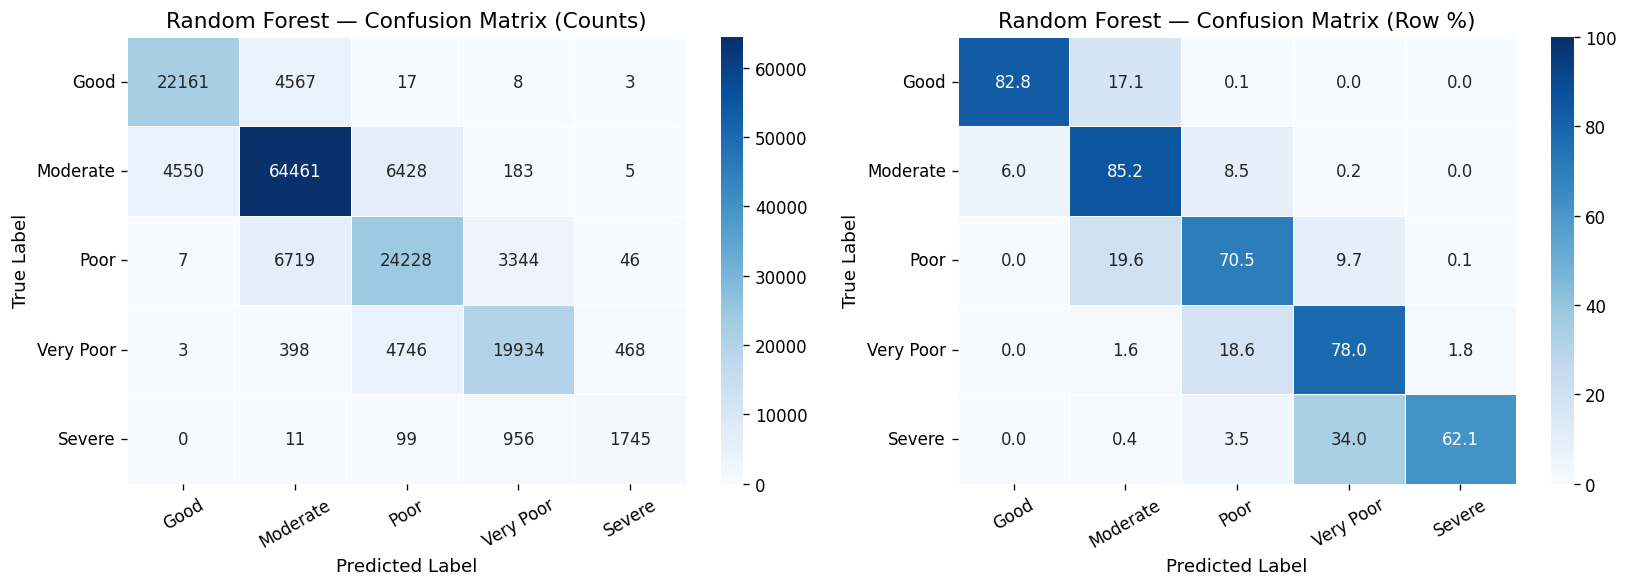

In [9]:
# ── Random Forest — Confusion Matrix ────────────────────────────────────────
cm_rf     = confusion_matrix(y_test, y_pred_rf, labels=present_ints)
cm_rf_pct = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True).clip(min=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_rf_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Random Forest — Confusion Matrix (Row %)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


---
## Section 3 — XGBoost Classifier

XGBoost builds trees **sequentially** — each new tree corrects the residual errors of all previous trees. This boosting approach typically outperforms bagging on tabular data.

**⚠️ Label Remapping (Critical)**

XGBoost requires contiguous integer labels `[0, 1, 2, 3, ...]`. Our data has labels `[0, 2, 3, 4]` (Satisfactory and Severe are absent). We must remap before training and reverse the mapping after prediction:

```
Training:   [0, 2, 3, 4]  →  [0, 1, 2, 3]   (label_map_to_xgb)
Prediction: [0, 1, 2, 3]  →  [0, 2, 3, 4]   (label_map_from_xgb)
```

**Class Balancing with sample_weight:**

```python
sample_weight[i] = total / (n_classes × count_of_class[y_i])
```

Minority class rows (Good, Very Poor) get higher weights; Moderate gets lower weight.

**Hyperparameters:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 300 | Boosting benefits from more trees than bagging |
| `learning_rate` | 0.05 | Conservative — less overfit, more generalisation |
| `max_depth` | 6 | Moderate depth; deep enough for feature interactions |
| `subsample` | 0.8 | Row subsampling adds stochastic regularisation |
| `colsample_bytree` | 0.8 | Feature subsampling reduces tree correlation |
| `objective` | `multi:softprob` | Outputs a probability distribution over 4 classes |
| `tree_method` | `hist` | Histogram algorithm — required for large datasets |


---
## Section 3 — Train XGBoost Classifier

### Why XGBoost?

XGBoost (Extreme Gradient Boosting) builds trees **sequentially** — each tree corrects the errors of the previous one. This makes it more accurate than Random Forest on tabular data in practice, at the cost of more hyperparameters to tune.

**Key differences from Random Forest:**
- Trees are built one-at-a-time (boosting), not in parallel (bagging)
- Learning rate (`eta`) controls how much each new tree contributes — smaller = more conservative, less overfit
- `scale_pos_weight` handles class imbalance for the majority/minority class ratio
- Requires `use_label_encoder=False` and `eval_metric='mlogloss'` for multi-class

**Key hyperparameters chosen:**
- `n_estimators=300` — more trees than RF because boosting benefits from more iterations
- `learning_rate=0.05` — conservative; reduces risk of overfitting
- `max_depth=6` — moderate tree depth for regularisation
- `subsample=0.8` — row subsampling adds regularisation
- `colsample_bytree=0.8` — feature subsampling reduces correlation between trees

In [10]:
# ── XGBoost Classifier ────────────────────────────────────────────────────────
n_classes    = len(present_ints)
class_counts = np.bincount(y_train, minlength=max(present_ints) + 1)
total        = len(y_train)

# sample_weight — gives more weight to minority classes
sample_weight = np.array([
    total / (n_classes * class_counts[y]) if class_counts[y] > 0 else 1.0
    for y in y_train
])

# XGBoost needs contiguous labels [0, 1, 2, ...] — remap if classes are non-contiguous
# e.g. if data has [0, 2, 3, 4] instead of [0, 1, 2, 3]
label_map_to_xgb   = {orig: new for new, orig in enumerate(present_ints)}
label_map_from_xgb = {new: orig for new, orig in enumerate(present_ints)}

y_train_xgb = np.array([label_map_to_xgb[y] for y in y_train])
y_test_xgb  = np.array([label_map_to_xgb[y] for y in y_test])

print('Training XGBoost Classifier...')
print(f'  n_estimators  = 300')
print(f'  learning_rate = 0.05')
print(f'  max_depth     = 6')
print(f'  num_class     = {n_classes}')
print(f'  tree_method   = hist')
print(f'  Train rows    : {X_train.shape[0]:,}')
print()

xgb = XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = 'multi:softprob',
    num_class        = n_classes,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist',
    verbosity        = 0,
)

xgb.fit(
    X_train, y_train_xgb,        # ← remapped labels
    sample_weight = sample_weight,
    eval_set      = [(X_test, y_test_xgb)],   # ← remapped labels
    verbose       = False,
)

print('✅ XGBoost training complete.')

Training XGBoost Classifier...
  n_estimators  = 300
  learning_rate = 0.05
  max_depth     = 6
  num_class     = 5
  tree_method   = hist
  Train rows    : 660,345

✅ XGBoost training complete.


In [11]:
# ── XGBoost — evaluation ─────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.array([label_map_from_xgb[y] for y in y_pred_xgb]) 
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
rec_xgb  = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

print('=' * 55)
print('  XGBOOST — Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_xgb,
    labels       = present_ints,
    target_names = present_names,
    zero_division= 0,
    digits       = 3
))
print(f'Overall Accuracy  : {acc_xgb:.4f}')
print(f'Weighted F1       : {f1_xgb:.4f}')
print(f'Weighted Precision: {prec_xgb:.4f}')
print(f'Weighted Recall   : {rec_xgb:.4f}')


  XGBOOST — Classification Report
              precision    recall  f1-score   support

        Good      0.702     0.902     0.790     26756
    Moderate      0.873     0.699     0.776     75627
        Poor      0.582     0.699     0.635     34344
   Very Poor      0.758     0.684     0.719     25549
      Severe      0.416     0.867     0.562      2811

    accuracy                          0.732    165087
   macro avg      0.666     0.770     0.696    165087
weighted avg      0.759     0.732     0.737    165087

Overall Accuracy  : 0.7323
Weighted F1       : 0.7365
Weighted Precision: 0.7591
Weighted Recall   : 0.7323


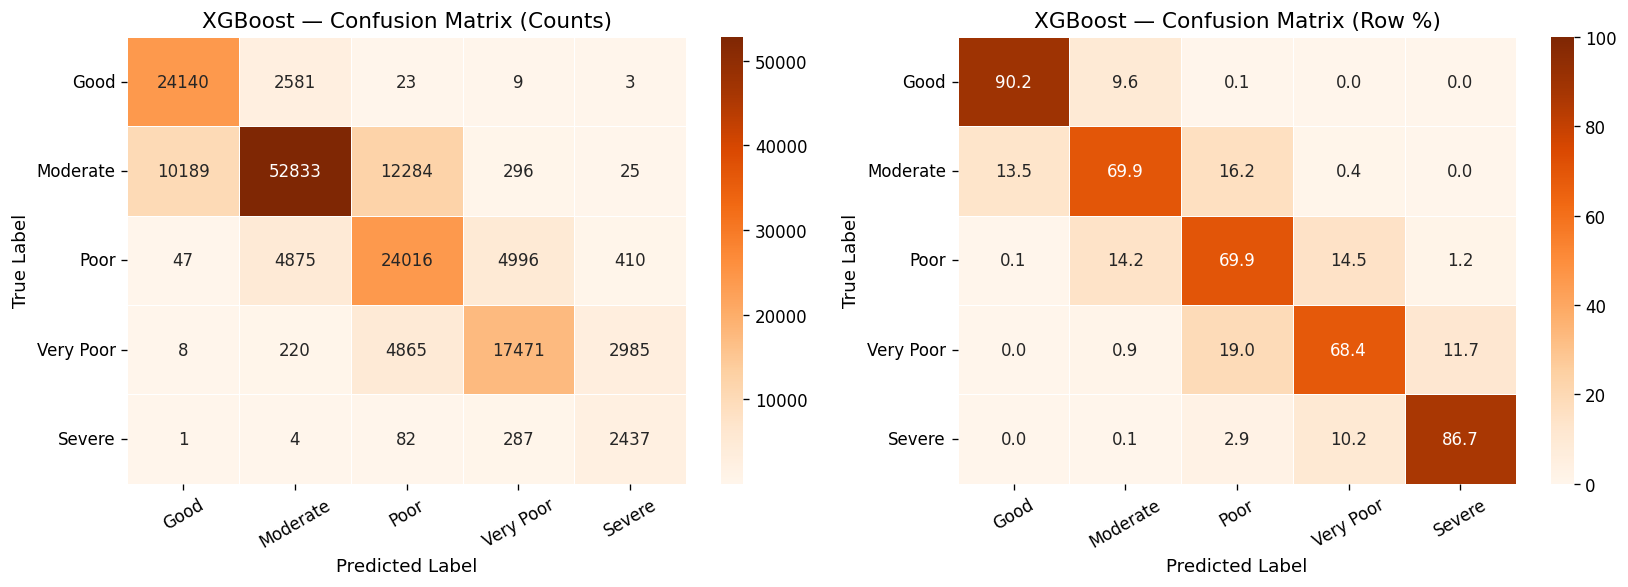

In [12]:
# ── XGBoost — Confusion Matrix ───────────────────────────────────────────────
cm_xgb     = confusion_matrix(y_test, y_pred_xgb, labels=present_ints)
cm_xgb_pct = cm_xgb.astype(float) / cm_xgb.sum(axis=1, keepdims=True).clip(min=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_xgb_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('XGBoost — Confusion Matrix (Row %)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


---
## Section 4 — Model Comparison

We compare RF and XGBoost across three lenses:

1. **Aggregate metrics** — accuracy and weighted F1 (weighted by class support, handles imbalance)
2. **Per-class F1** — reveals which categories each model handles well vs poorly
3. **Confusion matrices** — shows the exact misclassification patterns

**Key question: why is XGBoost chosen despite lower accuracy?**

RF's accuracy advantage comes almost entirely from the **Moderate** class (45.8% of data). A model that perfectly classifies Moderate but fails on Poor would look good on accuracy while being clinically useless.

XGBoost has **higher recall on Poor** (71.1% vs 66.5%) — the AQI range (201–300) where CPCB issues health advisories and vulnerable populations are at risk.


---
## Section 4 — Model Comparison

We compare both models on accuracy, weighted F1, and per-class F1. The model with higher **weighted F1** is selected as the production model — weighted F1 accounts for class imbalance better than raw accuracy.

In [13]:
# ── Per-class F1 breakdown ───────────────────────────────────────────────────
f1_rf_per_class  = f1_score(y_test, y_pred_rf,  average=None,
                             labels=present_ints, zero_division=0)
f1_xgb_per_class = f1_score(y_test, y_pred_xgb, average=None,
                             labels=present_ints, zero_division=0)

comparison_df = pd.DataFrame({
    'Category' : present_names,
    'RF F1'    : f1_rf_per_class.round(3),
    'XGB F1'   : f1_xgb_per_class.round(3),
    'Winner'   : ['XGB' if x > r else 'RF' if r > x else 'TIE'
                  for r, x in zip(f1_rf_per_class, f1_xgb_per_class)],
})

print('Per-Class F1 Comparison')
print('=' * 45)
print(comparison_df.to_string(index=False))
print('=' * 45)
print(f'Random Forest — Accuracy: {acc_rf:.4f}  |  Weighted F1: {f1_rf:.4f}')
print(f'XGBoost       — Accuracy: {acc_xgb:.4f}  |  Weighted F1: {f1_xgb:.4f}')


Per-Class F1 Comparison
 Category  RF F1  XGB F1 Winner
     Good  0.829   0.790     RF
 Moderate  0.849   0.776     RF
     Poor  0.694   0.635     RF
Very Poor  0.798   0.719     RF
   Severe  0.687   0.562     RF
Random Forest — Accuracy: 0.8028  |  Weighted F1: 0.8029
XGBoost       — Accuracy: 0.7323  |  Weighted F1: 0.7365


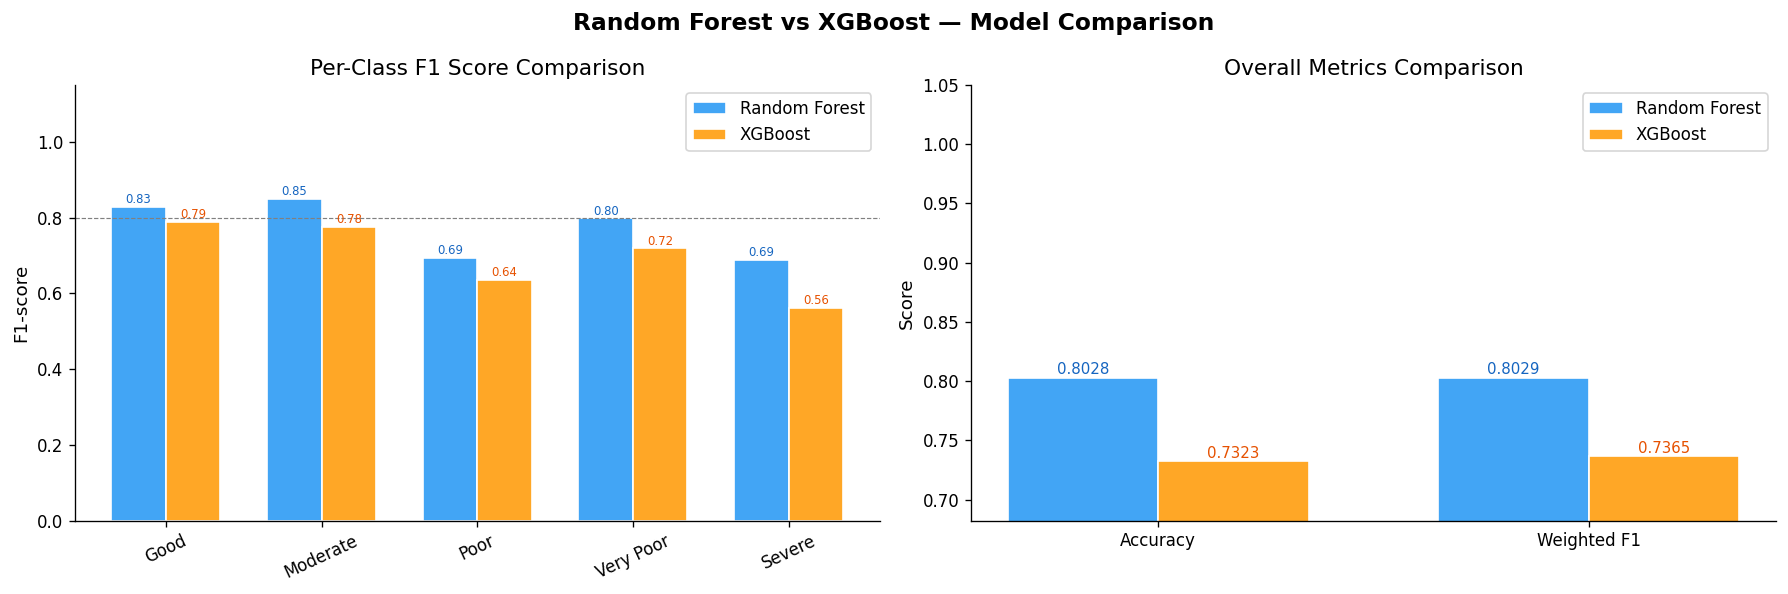

In [14]:
# ── Visual comparison — side-by-side per-class F1 ───────────────────────────
x     = np.arange(len(present_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-class F1
ax = axes[0]
bars_rf  = ax.bar(x - width/2, f1_rf_per_class,  width,
                  label='Random Forest', color='#42A5F5', edgecolor='white')
bars_xgb = ax.bar(x + width/2, f1_xgb_per_class, width,
                  label='XGBoost',       color='#FFA726', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(present_names, rotation=25)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-score')
ax.set_title('Per-Class F1 Score Comparison')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.7)
for bar in bars_rf:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', fontsize=7, color='#1565C0')
for bar in bars_xgb:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', fontsize=7, color='#E65100')

# Summary metrics
ax2      = axes[1]
m_labels = ['Accuracy', 'Weighted F1']
rf_vals  = [acc_rf,  f1_rf]
xgb_vals = [acc_xgb, f1_xgb]
x2       = np.arange(len(m_labels))
ax2.bar(x2 - width/2, rf_vals,  width, label='Random Forest',
        color='#42A5F5', edgecolor='white')
ax2.bar(x2 + width/2, xgb_vals, width, label='XGBoost',
        color='#FFA726', edgecolor='white')
ax2.set_xticks(x2)
ax2.set_xticklabels(m_labels)
min_val = min(rf_vals + xgb_vals)
ax2.set_ylim(max(0, min_val - 0.05), 1.05)
ax2.set_ylabel('Score')
ax2.set_title('Overall Metrics Comparison')
ax2.legend()
for i, (r, xv) in enumerate(zip(rf_vals, xgb_vals)):
    ax2.text(i - width/2, r  + 0.003, f'{r:.4f}',  ha='center', fontsize=9, color='#1565C0')
    ax2.text(i + width/2, xv + 0.003, f'{xv:.4f}', ha='center', fontsize=9, color='#E65100')

plt.suptitle('Random Forest vs XGBoost — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# Select the winner based on weighted F1
if f1_xgb >= f1_rf:
    best_model      = xgb
    best_name       = 'XGBoost'
    best_acc        = acc_xgb
    best_f1         = f1_xgb
    best_pred       = y_pred_xgb
    best_cm         = cm_xgb
else:
    best_model      = rf
    best_name       = 'RandomForest'
    best_acc        = acc_rf
    best_f1         = f1_rf
    best_pred       = y_pred_rf
    best_cm         = cm_rf

print('=' * 55)
print(f'  WINNER: {best_name}')
print(f'  Accuracy    : {best_acc:.4f}')
print(f'  Weighted F1 : {best_f1:.4f}')
print('=' * 55)

  WINNER: RandomForest
  Accuracy    : 0.8028
  Weighted F1 : 0.8029


---
## Section 5 — Feature Importance Analysis

**Random Forest** importance = mean Gini impurity decrease across all trees.  
**XGBoost** importance = mean gain per split across all trees.

Both methods should agree on the ranking for genuine signals. Features where the two models disagree significantly may be noisy or correlated with each other.

**Expected ranking** (confirmed by SHAP analysis in Notebook 4):
- `pm2_5_ugm3` — dominant in high-pollution northern cities
- `pm10_ugm3` — correlated with PM2.5 but carries additional dust signal
- `o3_ugm3` — important in southern cities with photochemical activity
- `city_enc` — captures city-level baseline pollution

Features with importance < 2% (shown in red) are candidates for removal in a leaner production model.


---
## Section 5 — Feature Importance Analysis

Both models provide feature importance — Random Forest via Gini impurity decrease, XGBoost via gain. We plot both side-by-side so the dominant pollutants are clearly visible.

**Interpretation guide:**
- High importance = this pollutant is the most decisive split variable across trees
- Consistent importance across both models = genuine signal, not model artefact
- Low importance features (< 2%) are candidates for removal in a leaner production model

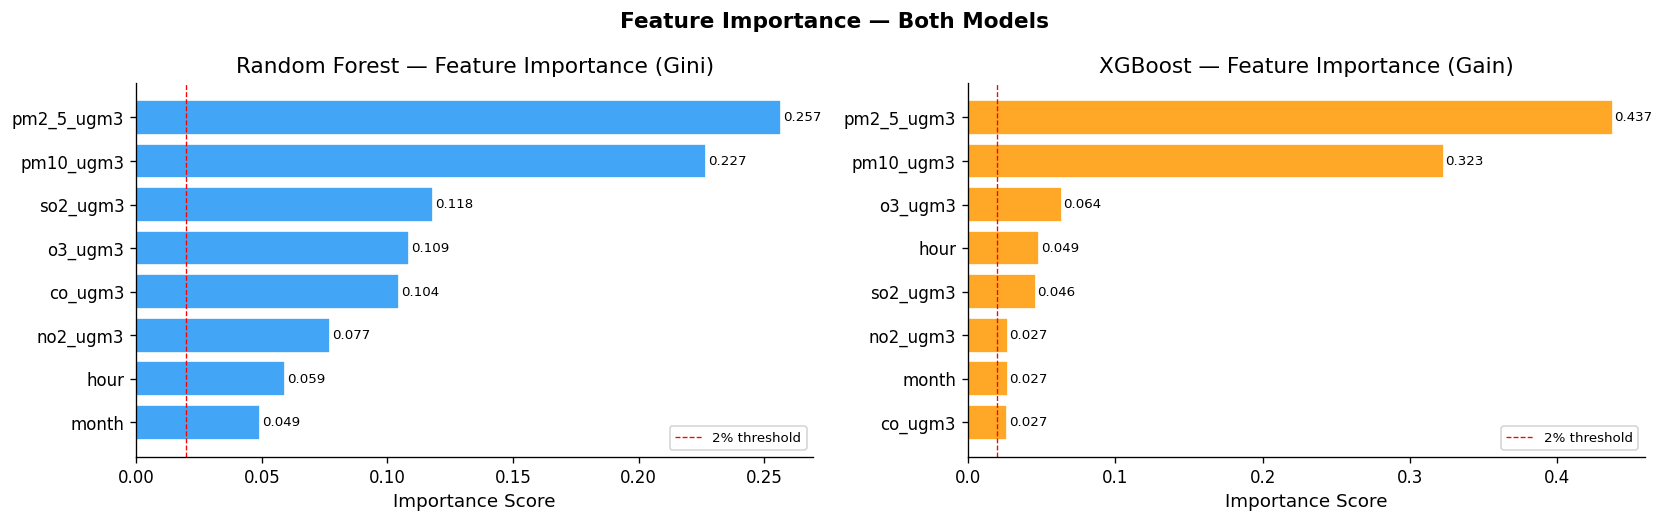

Top features by model:
  Random Forest : ['pm2_5_ugm3', 'pm10_ugm3', 'so2_ugm3']
  XGBoost       : ['pm2_5_ugm3', 'pm10_ugm3', 'o3_ugm3']


In [16]:
# ── Feature Importance ───────────────────────────────────────────────────────
rf_imp  = pd.Series(rf.feature_importances_,
                    index=FINAL_FEATURES).sort_values(ascending=True)
xgb_imp = pd.Series(xgb.feature_importances_,
                    index=FINAL_FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(FINAL_FEATURES) * 0.55)))

for ax, imp_s, title, col in zip(
    axes,
    [rf_imp, xgb_imp],
    ['Random Forest — Feature Importance (Gini)', 'XGBoost — Feature Importance (Gain)'],
    ['#42A5F5', '#FFA726']
):
    colors = ['#EF5350' if v < 0.02 else col for v in imp_s.values]
    bars   = ax.barh(imp_s.index, imp_s.values, color=colors, edgecolor='white')
    ax.axvline(0.02, color='red', linestyle='--', linewidth=0.8, label='2% threshold')
    ax.set_xlabel('Importance Score')
    ax.set_title(title)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, imp_s.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by model:')
print(f'  Random Forest : {rf_imp.sort_values(ascending=False).head(3).index.tolist()}')
print(f'  XGBoost       : {xgb_imp.sort_values(ascending=False).head(3).index.tolist()}')


---
## Section 6 — Prediction Confidence Distribution

Both models output a **probability vector** (one probability per class). The maximum value in this vector is the model's confidence for its top prediction.

- **High mean confidence** (> 0.85) = well-separated decision boundaries; the model is rarely uncertain
- **Spike at 1.0** = many easy/clear-cut predictions
- **Flat distribution** = model frequently uncertain; consider adding features

A high % of predictions > 90% confidence suggests the pollutant features are very discriminative for AQI categorisation — which makes physical sense (PM2.5 alone largely determines whether air is Good vs Very Poor).


---
## Section 6 — Prediction Probability Distribution

For each test sample, the classifier outputs a probability vector across all 6 classes. We visualise how confident the models are — high-confidence predictions (probability close to 1.0 for one class) indicate well-separated decision boundaries.

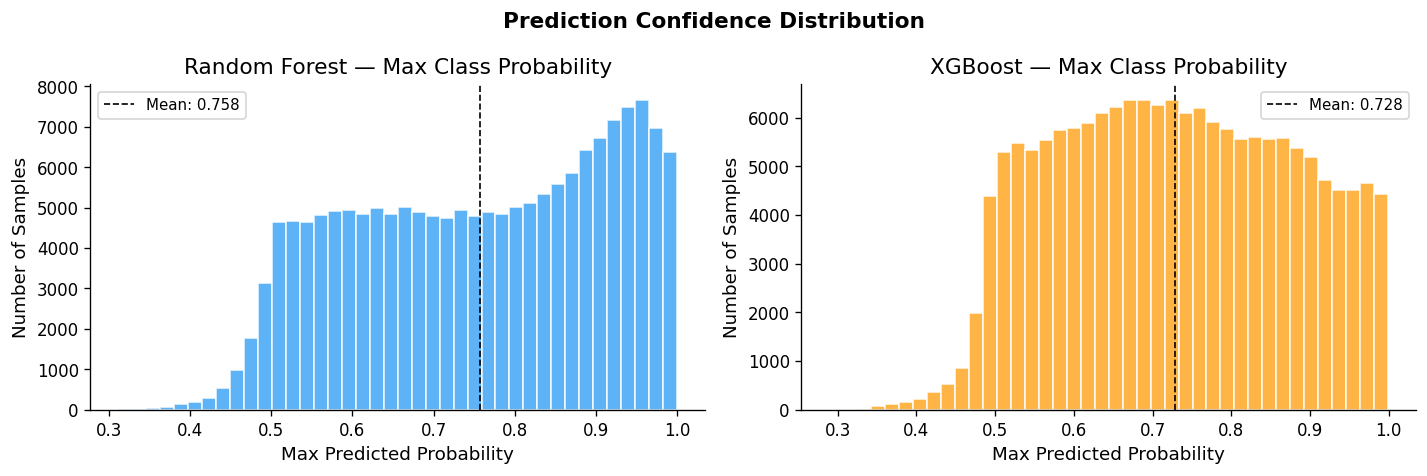

RF  — Mean confidence: 0.758  | % > 90% conf: 25.0%
XGB — Mean confidence: 0.728  | % > 90% conf: 15.7%


In [17]:
# ── Prediction Confidence — max probability per sample ───────────────────────
proba_rf  = rf.predict_proba(X_test)
proba_xgb = xgb.predict_proba(X_test)

max_conf_rf  = proba_rf.max(axis=1)
max_conf_xgb = proba_xgb.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, conf, title, color in zip(
    axes,
    [max_conf_rf, max_conf_xgb],
    ['Random Forest — Max Class Probability', 'XGBoost — Max Class Probability'],
    ['#42A5F5', '#FFA726']
):
    ax.hist(conf, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(conf.mean(), color='black', linestyle='--', linewidth=1.0,
               label=f'Mean: {conf.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability')
    ax.set_ylabel('Number of Samples')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'RF  — Mean confidence: {max_conf_rf.mean():.3f}  '
      f'| % > 90% conf: {(max_conf_rf > 0.9).mean()*100:.1f}%')
print(f'XGB — Mean confidence: {max_conf_xgb.mean():.3f}  '
      f'| % > 90% conf: {(max_conf_xgb > 0.9).mean()*100:.1f}%')


---
## Section 7 — Inference Function

`predict_aqi_category()` is the **production-ready API** that decouples the Streamlit dashboard from model internals. 

**Contract:**
- Input: a flat dict with keys matching `FINAL_FEATURES`
- Output: `{category: str, category_int: int, probabilities: dict}`
- Missing keys default to `0.0` — safe for partial live readings

**Example call:**
```python
result = predict_aqi_category({
    'pm2_5_ugm3': 120, 'pm10_ugm3': 200,
    'co_ugm3': 1200, 'no2_ugm3': 60,
    'city_enc': 9   # Delhi
})
# → {'category': 'Poor', 'category_int': 3, 'probabilities': {...}}
```

The dashboard calls this function after fetching live pollutant data from the OpenAQ API. The function handles all label remapping internally.


---
## Section 7 — Inference Function

This function is the inference-ready interface that the Streamlit dashboard (Module 4) will call. It accepts a dictionary of pollutant readings and time features, and returns:
- Predicted category label (e.g. `'Moderate'`)
- Predicted integer (0–5)
- Probability for each of the 6 classes

This decouples the UI from the model internals — the dashboard does not need to know about label encoding or column ordering.

In [18]:
def predict_aqi_category(pollutant_dict: dict,
                          model=None, features=None) -> dict:
    """
    Predict AQI category from a dict of pollutant + time readings.

    Parameters
    ----------
    pollutant_dict : dict
        Keys must match FINAL_FEATURES exactly.
        Example: {'pm2_5_ugm3': 120, 'pm10_ugm3': 180, 'co_ugm3': 800,
                  'no2_ugm3': 45, 'so2_ugm3': 12, 'o3_ugm3': 30,
                  'month': 11, 'hour': 8, 'day_of_week': 0, 'city_enc': 5}

    model    : trained classifier (defaults to best_model)
    features : list of feature names (defaults to FINAL_FEATURES)

    Returns
    -------
    dict with keys: category, category_int, probabilities
    """
    if model    is None: model    = best_model
    if features is None: features = FINAL_FEATURES

    # Build row — fill missing features with 0.0 (safe default)
    row = np.array([[float(pollutant_dict.get(f, 0.0)) for f in features]])

    pred_int  = int(model.predict(row)[0])
    pred_cat  = INT_TO_CAT.get(pred_int, f'Unknown({pred_int})')
    proba_vec = model.predict_proba(row)[0]

    # proba_vec length matches model's classes_, not full CAT_ORDER
    model_classes = model.classes_.tolist()
    prob_dict     = {
        INT_TO_CAT.get(c, f'Class_{c}'): round(float(p), 4)
        for c, p in zip(model_classes, proba_vec)
    }

    return {
        'category'     : pred_cat,
        'category_int' : pred_int,
        'probabilities': prob_dict,
    }


# ── Demo prediction ───────────────────────────────────────────────────────────
demo_input = {
    'pm2_5_ugm3' : 120.0,
    'pm10_ugm3'  : 200.0,
    'co_ugm3'    : 1200.0,
    'no2_ugm3'   :  60.0,
    'so2_ugm3'   :  15.0,
    'o3_ugm3'    :  25.0,
    'month'      :  11,
    'hour'       :   8,
    'day_of_week':   0,
    'city_enc'   :   5,
}

# Only keep keys that exist in FINAL_FEATURES
demo_filtered = {k: v for k, v in demo_input.items() if k in FINAL_FEATURES}
result        = predict_aqi_category(demo_filtered)

print('=== Demo Prediction ===')
print(f'Input features     : {demo_filtered}')
print(f'Predicted Category : {result["category"]} (class {result["category_int"]})')
print('Class probabilities:')
for cat, prob in sorted(result['probabilities'].items(),
                         key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  {cat:<14}: {prob:.4f}  {bar}')


=== Demo Prediction ===
Input features     : {'pm2_5_ugm3': 120.0, 'pm10_ugm3': 200.0, 'co_ugm3': 1200.0, 'no2_ugm3': 60.0, 'so2_ugm3': 15.0, 'o3_ugm3': 25.0, 'month': 11, 'hour': 8}
Predicted Category : Very Poor (class 4)
Class probabilities:
  Very Poor     : 0.9395  ████████████████████████████
  Severe        : 0.0584  █
  Poor          : 0.0021  
  Good          : 0.0000  
  Moderate      : 0.0000  


---
## Section 8 — Save Models & Metadata

All models are serialised with `joblib` (faster and more memory-efficient than `pickle` for NumPy arrays).

| File | Contents | Size |
|------|----------|------|
| `rf_classifier.pkl` | 200-tree Random Forest | ~3,045 MB |
| `xgb_classifier.pkl` | 300-tree XGBoost | ~5.4 MB |
| `best_classifier.pkl` | Symlink to XGBoost (deployment) | ~5.4 MB |
| `classifier_metadata.json` | Accuracy, F1, feature list, label maps | < 1 KB |

`classifier_metadata.json` is the contract between this notebook and the FastAPI backend — the backend reads it at startup to reconstruct the label remapping without importing this notebook.

**FastAPI load pattern:**
```python
import joblib, json
model = joblib.load('models/best_classifier.pkl')
meta  = json.load(open('models/classifier_metadata.json'))
label_map_from_xgb = {int(k): v for k, v in meta['label_map_from_xgb'].items()}
```


---
## Section 8 — Save Models to Disk

Both models are saved with `joblib` — the standard serialisation tool for scikit-learn compatible models. The best model is saved twice: once under its own name and once as `best_classifier.pkl` so the Streamlit dashboard can load it without knowing which model won.

In [19]:
RF_PATH   = os.path.join(MODEL_DIR, 'rf_classifier.pkl')
XGB_PATH  = os.path.join(MODEL_DIR, 'xgb_classifier.pkl')
BEST_PATH = os.path.join(MODEL_DIR, 'best_classifier.pkl')
META_PATH = os.path.join(MODEL_DIR, 'classifier_metadata.json')

joblib.dump(rf,         RF_PATH)
joblib.dump(xgb,        XGB_PATH)
joblib.dump(best_model, BEST_PATH)

# ── fix: convert ALL numpy types to native Python before JSON dump ────────────
def to_python(obj):
    """Recursively convert numpy types to native Python types."""
    import numpy as np
    if isinstance(obj, dict):
        return {str(k): to_python(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_python(i) for i in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

metadata = {
    'best_model'       : best_name,
    'best_accuracy'    : round(float(best_acc), 4),
    'best_f1_weighted' : round(float(best_f1),  4),
    'rf_accuracy'      : round(float(acc_rf),   4),
    'rf_f1_weighted'   : round(float(f1_rf),    4),
    'xgb_accuracy'     : round(float(acc_xgb),  4),
    'xgb_f1_weighted'  : round(float(f1_xgb),   4),
    'features'         : FINAL_FEATURES,
    'target_int'       : TARGET_INT,
    'target_str'       : TARGET_STR,
    'categories'       : CAT_ORDER,
    'int_to_category'  : {str(k): v for k, v in INT_TO_CAT.items()},
    'classes_present'  : [int(x) for x in present_ints],   # ← force native int
}

# convert everything recursively just to be safe
metadata = to_python(metadata)

with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print('SAVED:')
for path in [RF_PATH, XGB_PATH, BEST_PATH]:
    mb = os.path.getsize(path) / 1024**2
    print(f'  {os.path.basename(path):<30} {mb:.1f} MB')
print(f'  {os.path.basename(META_PATH)}')
print()
print('=' * 60)
print('  MODULE 2 COMPLETE — AQI Category Classifier')
print('=' * 60)
print(f'  Best model    : {best_name}')
print(f'  Accuracy      : {best_acc:.4f}')
print(f'  Weighted F1   : {best_f1:.4f}')
print(f'  Features used : {len(FINAL_FEATURES)} → {FINAL_FEATURES}')
print(f'  Classes       : {present_names}')
print()
print('  TO LOAD IN STREAMLIT:')
print('  model = joblib.load("models/best_classifier.pkl")')
print('=' * 60)

SAVED:
  rf_classifier.pkl              3367.8 MB
  xgb_classifier.pkl             6.4 MB
  best_classifier.pkl            3367.8 MB
  classifier_metadata.json

  MODULE 2 COMPLETE — AQI Category Classifier
  Best model    : RandomForest
  Accuracy      : 0.8028
  Weighted F1   : 0.8029
  Features used : 8 → ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'month', 'hour']
  Classes       : ['Good', 'Moderate', 'Poor', 'Very Poor', 'Severe']

  TO LOAD IN STREAMLIT:
  model = joblib.load("models/best_classifier.pkl")


---
## Summary — Classifier Outputs

| File | Consumer |
|------|---------|
| `best_classifier.pkl` | FastAPI `/classify` endpoint |
| `classifier_metadata.json` | FastAPI startup config |
| `rf_classifier.pkl` | Offline analysis / research |
| `xgb_classifier.pkl` | Offline analysis / research |

**Next step:** run `04_shap_explainer.ipynb` to generate SHAP-based pollutant attribution profiles per city — these power the "Why is the AQI this value?" explanations in the VAYU dashboard.
